In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.ops import nearest_points

In [2]:
# Load pothole work order data
potholes = gpd.read_file("../data/raw/Street_Pothole_Work_Orders_-_Closed_(Dataset).geojson")

print(f"data loaded: {len(potholes)} rows x {len(potholes.columns)} columns")
potholes.head()

data loaded: 401594 rows x 19 columns


,:id,:version,:created_at,:updated_at,defnum,initby,housenum,oft,onfacename,onprimname,frmprimnam,toprimname,specloc,boro,source,rptdate,rptclosed,shape_leng,geometry
0,row-jx8m.gdpq-y3ua,rv-6qef~j48j_5b9e,2026-04-30 19:41:04.386000+00:00,2026-04-30 19:41:04.386000+00:00,DB2004041154,YRD,None,373480377030377030,ROCKAWAY PY,ROCKAWAY PARKWAY,BELT PARKWAY,BELT PARKWAY,None,B,YRD,2004-02-08,2023-01-27,557.690464852,"MULTILINESTRING ((-73.88643 40.63078, -73.8860..."
1,row-mi7k_dc5y~e33f,rv-dzgk~n5m2_gvx9,2026-04-30 19:41:04.386000+00:00,2026-04-30 19:41:04.386000+00:00,DB2004287021,CSC,None,318630377030377030,BEDFORD AV,BEDFORD AVENUE,BELT PARKWAY,BELT PARKWAY,SB ON BEDFORD_UNDERNEATH OVERPASS,B,CTZ,2004-10-13,2013-02-14,109.124234309,"MULTILINESTRING ((-73.94381 40.58499, -73.9438..."
2,row-8wxg_rmxu_et2s,rv-wxhh_pdb9.2rzt,2026-04-30 19:41:04.386000+00:00,2026-04-30 19:41:04.386000+00:00,DB2006085009,CSC,None,306380308480308530,13 AV,13 AVENUE,38 STREET,39 STREET,I/F/O B16 BUS STOP,B,CTZ,2006-03-26,2014-10-11,260.495098096,"MULTILINESTRING ((-73.98571 40.64119, -73.9862..."
3,row-w2jj_j5em~gjk4,rv-bwbx_nhbh.sbcs,2026-04-30 19:41:04.386000+00:00,2026-04-30 19:41:04.386000+00:00,DB2007166005,CSC,1688,342730355530375430,FULTON ST,FULTON STREET,LEWIS AVENUE,SCHENECTADY AVENUE,POTHOLE NEAR CURB I/F/O ADDRESS,B,CTZ,2007-06-15,2011-01-14,549.255973307,"MULTILINESTRING ((-73.93487 40.67959, -73.9343..."
4,row-mje4.qtar~cgsu,rv-kse4.pez2_yrib,2026-04-30 19:41:04.386000+00:00,2026-04-30 19:41:04.386000+00:00,DB2009352004,CSC,45,380030331530342730,ST FELIX ST,ST FELIX STREET,DEKALB AVENUE,FULTON STREET,"4"" DEEP",B,CTZ,2009-12-18,2010-01-06,836.436669174,"MULTILINESTRING ((-73.97794 40.68981, -73.9775..."


In [3]:
# Clean pothole work order data and cast data types
potholes = potholes.drop(columns = [col for col in potholes.columns if col[0] == ":"]) # drop metadata cols 

dtype_schema = {
    "numeric": ["shape_leng"],
    "category": ["boro"],
    "datetime": ["rptdate", "rptclosed"],
    "object": ["defnum", "initby", "housenum", "oft", "onfacename", "onprimname", "frmprimnam", "toprimname", "specloc", "source"]
}

for col in potholes.columns:
    if col == "geometry":
        continue # leave geometry untouched
    elif col in dtype_schema["numeric"]:
        potholes[col] = pd.to_numeric(potholes[col]) 
    elif col in dtype_schema["category"]:
        potholes[col] = potholes[col].astype("category") 
    elif col in dtype_schema["datetime"]:
        potholes[col] = pd.to_datetime(potholes[col])
    elif col in dtype_schema["object"]:
        potholes[col] = potholes[col].astype(str)
    else: 
        print(f"Warning: {col} not in schema")

# Create new cols
potholes["response_time"] = ((potholes["rptclosed"] - potholes["rptdate"])).dt.days

In [4]:
# Load road centerlines
roads = gpd.read_file("../data/raw/Centerline.geojson")

print(f"data loaded: {len(roads)} rows x {len(roads.columns)} columns")
roads.head()

data loaded: 122264 rows x 68 columns


,:id,:version,:created_at,:updated_at,physicalid,l_low_hn,l_high_hn,r_low_hn,r_high_hn,l_zip,...,post_modifier,full_street_name,bike_trafdir,shape_length,globalid,segment_type,segment_type_value,street_name,stname_label,geometry
0,row-d8pp~guz6~g7kk,rv-rcad-w8k9~javh,2025-04-10 17:47:57.847000+00:00,2025-04-10 17:47:57.847000+00:00,46810,901,999,900,998,11230,...,None,AVE N,None,104.31497003950751,cedc2dde-7e8b-4427-af4c-c7fe5174b2c7,None,None,N,AVE N,"MULTILINESTRING ((-73.96529 40.615, -73.96436 ..."
1,row-dy5v.zbku.5n69,rv-b4mq.zz7q.jvka,2025-04-10 17:47:57.847000+00:00,2025-04-10 17:47:57.847000+00:00,86757,2501,2599,2500,2598,10469,...,None,HONE AVE,None,359.45658741153875,9c163e85-23ad-418a-a54c-40c8eef802e5,None,None,HONE,HONE AVE,"MULTILINESTRING ((-73.85781 40.86304, -73.8577..."
2,row-ugkn_f2rh.tehx,rv-f4u6~2nzz~5w6p,2025-04-10 17:47:57.847000+00:00,2025-04-10 17:47:57.847000+00:00,84282,22-001,22-099,22-000,22-098,11105,...,None,48 ST,None,277.53323334462675,fdccf94f-201f-4312-a96d-0c26d0fa7cfd,None,None,48,48 ST,"MULTILINESTRING ((-73.90105 40.76932, -73.9027..."
3,row-i57g-pha3-pwik,rv-7eep-c95m-d4cx,2025-04-10 17:47:57.847000+00:00,2025-04-10 17:47:57.847000+00:00,79741,79,107,78,100,10013,...,None,LAIGHT ST,None,120.04580684369262,bcbbb800-b963-45bf-804e-42f5ada6c207,None,None,LAIGHT,LAIGHT ST,"MULTILINESTRING ((-74.01056 40.72221, -74.0116..."
4,row-nkti~vqqc-gmcy,rv-6cbn_7528-mu5v,2025-11-01 19:04:39.424000+00:00,2025-11-01 19:04:39.424000+00:00,184200,0,0,74,86,10306,...,None,BROOK AVE,None,90.288796296633848,d7f8c5d8-637b-4122-950f-faf2206c8561,None,None,BROOK,BROOK AVE,"MULTILINESTRING ((-74.12161 40.55847, -74.1215..."


In [5]:
# Clean road data
roads = roads.drop(columns = [col for col in roads.columns if col[0] == ":"]) # drop metadata cols 
roads = roads[~pd.to_numeric(roads["rw_type"]).isin([5, 6, 8, 12, 14])] # remove boardwalks, trails, driveways, non-physical segments, and ferry routes

# Create new cols
roads["lane_miles"] = (roads["segmentlength"].astype(float) / 5280) * (pd.to_numeric(roads["number_total_lanes"], errors="coerce").fillna(0))

In [6]:
# Calculate lane miles by borough
boros = {
    "1" : "Manhattan", 
    "2" : "Bronx", 
    "3" : "Brooklyn", 
    "4" : "Queens", 
    "5" : "Staten Island"
    }

boro_roads = roads.groupby("boroughcode").agg(lane_miles=("lane_miles", "sum")).reset_index()
boro_roads["borough"] = boro_roads["boroughcode"].map(boros)
boro_roads =  boro_roads.set_index("borough")
boro_roads =  boro_roads.drop(columns = "boroughcode")
boro_roads["lane_miles_pct"] = boro_roads["lane_miles"] / sum(boro_roads["lane_miles"].values)

boro_roads

,lane_miles,lane_miles_pct
borough,,
Manhattan,2050.577402,0.096099
Bronx,2991.711836,0.140205
Brooklyn,5266.465127,0.246810
Queens,7970.311613,0.373524
Staten Island,3059.075515,0.143362


In [7]:
# Filter for work orders filled during blitzes
blitz_map = {
    pd.to_datetime("2026-03-14") : 1,
    pd.to_datetime("2026-03-21") : 2, 
    pd.to_datetime("2026-03-28") : 3, 
    pd.to_datetime("2026-04-11") : 4
}

blitz_potholes = potholes[potholes["rptclosed"].isin(blitz_map.keys())].copy()
blitz_potholes["blitz_number"] = blitz_potholes["rptclosed"].map(blitz_map)

print(f"There are {len(blitz_potholes)} work orders identified across all blitzes")
blitz_potholes.head()

There are 1778 work orders identified across all blitzes


,defnum,initby,housenum,oft,onfacename,onprimname,frmprimnam,toprimname,specloc,boro,source,rptdate,rptclosed,shape_leng,geometry,response_time,blitz_number
106390,DB2026062083,CSC,None,358730353030372930,MARCY AV,MARCY AVENUE,JEFFERSON AVENUE,PUTNAM AVENUE,None,B,CTZ,2026-03-03,2026-03-14,270.132102,"MULTILINESTRING ((-73.94702 40.68438, -73.9468...",11,1
106575,DB2026065171,ONF,None,373690319630385530,ROGERS AV,ROGERS AVENUE,BEVERLEY ROAD,TILDEN AVENUE,LEFT DRIVING LANE,B,CTZ,2026-03-06,2026-03-14,664.154214,"MULTILINESTRING ((-73.95205 40.64677, -73.9518...",8,1
106578,DB2026065176,ONF,None,373690319230380430,ROGERS AV,ROGERS AVENUE,BERGEN STREET,ST MARKS AVENUE,CENTER OF ROADWAY,B,CTZ,2026-03-06,2026-03-14,325.258645,"MULTILINESTRING ((-73.95269 40.67625, -73.9527...",8,1
106579,DB2026065177,ONF,None,326730331530393230,CLASSON AV,CLASSON AVENUE,DEKALB AVENUE,WILLOUGHBY AVENUE,None,B,CTZ,2026-03-06,2026-03-14,766.978337,"MULTILINESTRING ((-73.96074 40.69242, -73.9602...",8,1
106584,DB2026066009,ONF,None,367730354630369730,OCEAN PY,OCEAN PARKWAY,LAWRENCE AVENUE,PARKVILLE AVENUE,MIDDLE LANE,B,CTZ,2026-03-07,2026-03-14,549.120382,"MULTILINESTRING ((-73.97211 40.63137, -73.9719...",7,1


In [8]:
# Calculate blitz pothole work orders by boro
boro_map = {
    "B" : "Brooklyn",
    "M" : "Manhattan", 
    "Q" : "Queens", 
    "S" : "Staten Island",
    "X" : "Bronx"
}

boro_blitz_potholes = blitz_potholes.groupby("boro", observed=False).agg(work_order_count=("defnum", "count")).reset_index()
boro_blitz_potholes["borough"] = boro_blitz_potholes["boro"].map(boro_map)
boro_blitz_potholes =  boro_blitz_potholes.set_index("borough")
boro_blitz_potholes =  boro_blitz_potholes.drop(columns = "boro")

boro_blitz_potholes["work_order_pct"] = boro_blitz_potholes["work_order_count"] / sum(boro_blitz_potholes["work_order_count"].values)

boro_blitz_potholes

,work_order_count,work_order_pct
borough,,
Brooklyn,449,0.252531
Manhattan,172,0.096738
Queens,637,0.358268
Staten Island,338,0.190101
Bronx,182,0.102362


In [9]:
# Compare work orders to lane miles
boro_compare = pd.merge(boro_blitz_potholes, boro_roads, on="borough")
boro_compare = boro_compare.drop(columns = ["work_order_count", "lane_miles"])
boro_compare["difference"] = boro_compare["work_order_pct"] - boro_compare["lane_miles_pct"]

boro_compare

,work_order_pct,lane_miles_pct,difference
borough,,,
Brooklyn,0.252531,0.246810,0.005721
Manhattan,0.096738,0.096099,0.000639
Queens,0.358268,0.373524,-0.015256
Staten Island,0.190101,0.143362,0.046739
Bronx,0.102362,0.140205,-0.037843


In [11]:
# Spatial join blitz work orders to roads
blitz_potholes_2263 = blitz_potholes.to_crs(epsg=2263) #reproject to NAD83 / New York Long Island (ftUS) for spatial join
roads_2263 = roads.to_crs(epsg=2263)  #reproject to NAD83 / New York Long Island (ftUS) for spatial join

blitz_potholes_joined = gpd.sjoin_nearest(
    blitz_potholes_2263,
    roads_2263[["physicalid", "number_total_lanes", "trafdir", "bike_lane", "rw_type", "geometry"]],
    how="left",
    max_distance=10,
    distance_col="distance"
)

blitz_potholes_joined = blitz_potholes_joined.sort_values("distance").drop_duplicates(subset="defnum", keep="first") # keep only nearest match
print(f"{len(blitz_potholes_joined[blitz_potholes_joined["physicalid"].notna()])} of {len(blitz_potholes_joined)} ({(len(blitz_potholes_joined[blitz_potholes_joined["physicalid"].notna()])/len(blitz_potholes_joined)):.2%}) blitz work order street segments were matched with road segments")

# Explore overlap of blitz work orders and bike lanes
print(f"There are {len(blitz_potholes_joined[pd.to_numeric(blitz_potholes_joined["bike_lane"], errors="coerce").notna()])} blitz work orders on roads with bike lanes")

# Explore overlap of blitz work orders and major roads
print(f"There are {len(blitz_potholes_joined[pd.to_numeric(blitz_potholes_joined['rw_type'], errors='coerce') == 2])} blitz work orders on highways")
print(f"There are {len(blitz_potholes_joined[pd.to_numeric(blitz_potholes_joined['number_total_lanes'], errors='coerce') > 2])} blitz work orders on roads with 3+ lanes")

1768 of 1778 (99.44%) blitz work order street segments were matched with road segments
There are 253 blitz work orders on roads with bike lanes
There are 4 blitz work orders on highways
There are 1450 blitz work orders on roads with 3+ lanes


In [12]:
# Spatial join all work orders to roads
potholes_2263 = potholes.to_crs(epsg=2263) #reproject to NAD83 / New York Long Island (ftUS) for spatial join
roads_2263 = roads.to_crs(epsg=2263)  #reproject to NAD83 / New York Long Island (ftUS) for spatial join

all_potholes_joined = gpd.sjoin_nearest(
    potholes_2263,
    roads_2263[["physicalid", "number_total_lanes", "trafdir", "bike_lane", "rw_type", "geometry"]],
    how="left",
    max_distance=10,
    distance_col="distance"
)

all_potholes_joined = all_potholes_joined.sort_values("distance").drop_duplicates(subset="defnum", keep="first") # keep only nearest match
print(f"{len(all_potholes_joined[all_potholes_joined["physicalid"].notna()])} of {len(all_potholes_joined)} ({(len(all_potholes_joined[all_potholes_joined["physicalid"].notna()])/len(all_potholes_joined)):.2%}) overall pothole work order street segments were matched with road segments")

# Explore overlap of blitz work orders and bike lanes
print(f"There are {len(all_potholes_joined[pd.to_numeric(all_potholes_joined["bike_lane"], errors="coerce").notna()])} overall pothole work orders on roads with bike lanes")

# Explore overlap of blitz work orders and major roads
print(f"There are {len(all_potholes_joined[pd.to_numeric(all_potholes_joined['rw_type'], errors='coerce') == 2])} overall pothole work orders on highways")
print(f"There are {len(all_potholes_joined[pd.to_numeric(all_potholes_joined['number_total_lanes'], errors='coerce') > 2])} overall pothole work orders on roads with 3+ lanes")

399930 of 401594 (99.59%) overall pothole work order street segments were matched with road segments
There are 68580 overall pothole work orders on roads with bike lanes
There are 2080 overall pothole work orders on highways
There are 332566 overall pothole work orders on roads with 3+ lanes


In [13]:
# Create comparison of overall and blitz work orders for bike lanes and major roads
summary = pd.DataFrame({
    "metric": ["Bike lanes", "Highways", "3+ lanes"],
    "blitz_count": [
        len(blitz_potholes_joined[pd.to_numeric(blitz_potholes_joined["bike_lane"], errors="coerce").notna()]),
        len(blitz_potholes_joined[pd.to_numeric(blitz_potholes_joined["rw_type"], errors="coerce") == 2]),
        len(blitz_potholes_joined[pd.to_numeric(blitz_potholes_joined["number_total_lanes"], errors="coerce") > 2])
    ],
    "overall_count": [
        len(all_potholes_joined[pd.to_numeric(all_potholes_joined["bike_lane"], errors="coerce").notna()]),
        len(all_potholes_joined[pd.to_numeric(all_potholes_joined["rw_type"], errors="coerce") == 2]),
        len(all_potholes_joined[pd.to_numeric(all_potholes_joined["number_total_lanes"], errors="coerce") > 2])
    ],
    "blitz_total": len(blitz_potholes_joined),
    "overall_total": len(all_potholes_joined)
})

summary["blitz_pct"] = summary["blitz_count"] / summary["blitz_total"]
summary["overall_pct"] = summary["overall_count"] / summary["overall_total"]
summary["pct_diff"] = summary["blitz_pct"] - summary["overall_pct"]

summary

,metric,blitz_count,overall_count,blitz_total,overall_total,blitz_pct,overall_pct,pct_diff
0,Bike lanes,253,68580,1778,401594,0.142295,0.170769,-0.028475
1,Highways,4,2080,1778,401594,0.002250,0.005179,-0.002930
2,3+ lanes,1450,332566,1778,401594,0.815523,0.828115,-0.012592


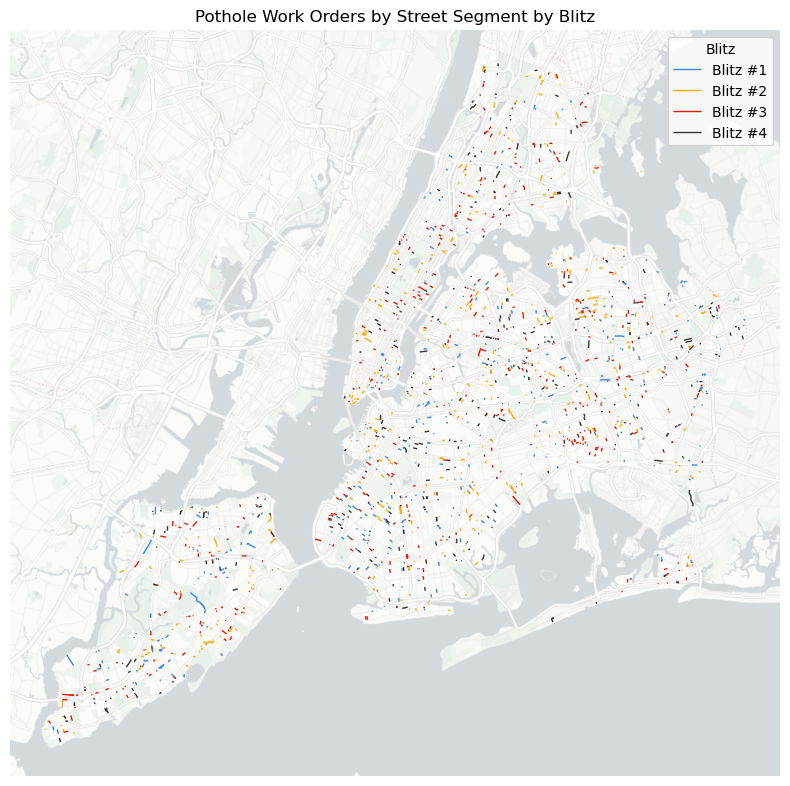

In [14]:
# Map blitz work orders by blitz
fig, ax = plt.subplots(figsize=(8, 8))

colors = {1: "#378ADD", 2: "#FFAC00", 3: "#E71801", 4: "#373434"}

for blitz, group in blitz_potholes.groupby("blitz_number"):
    group.to_crs(epsg=3857).plot(ax=ax, color=colors[blitz], label=f"Blitz #{blitz}", markersize=2, linewidth=1)

ctx.add_basemap(ax, source="https://a.basemaps.cartocdn.com/light_nolabels/{z}/{x}/{y}.png")

ax.set_title("Pothole Work Orders by Street Segment by Blitz")
ax.legend(title="Blitz")
ax.axis("off")
plt.tight_layout()
plt.show()

In [16]:
# Export Data
blitz_potholes.to_file("../data/processed/nyc_blitz_potholes.geojson", driver="GeoJSON")